In [ ]:
import pip
import sys
import pandas as pd
import numpy as np
import os
import json
import matplotlib.pyplot as plt
import pickle

In [ ]:
import tensorflow as tf

In [ ]:
from google.colab import drive
import zipfile

# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DATA_PATH = "/content/drive/MyDrive/Tugas SMT 6/Propen/dataset_cva_hs.pkl"

with open(DATA_PATH, "rb") as f:
    dataset_cva_hs = pickle.load(f)

print("Jumlah trial:", len(dataset_cva_hs))

Jumlah trial: 488


#**Preprocessing**

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import pandas as pd

WINDOW_SIZE = 400
STEP_SIZE = 200

X_sensor_list = []
y_list = []
group_list = []
meta_records = []

for trial in dataset_cva_hs:
    sensor_matrix = trial["sensor_matrix"]
    subject_id = trial["subject_id"]
    fma_score = trial["fma_score"]
    meta = trial["meta_features"]

    sensor_data = sensor_matrix[:, :9]
    uturn_flag = sensor_matrix[:, 9].reshape(-1, 1)

    scaler = StandardScaler()
    sensor_scaled = scaler.fit_transform(sensor_data)

    matrix_processed = np.hstack((sensor_scaled, uturn_flag))

    num_rows = matrix_processed.shape[0]

    for start in range(0, num_rows - WINDOW_SIZE + 1, STEP_SIZE):
        end = start + WINDOW_SIZE
        window = matrix_processed[start:end, :]

        X_sensor_list.append(window)
        y_list.append(fma_score)
        group_list.append(subject_id)
        meta_records.append(meta)

X_sensor = np.array(X_sensor_list)
y = np.array(y_list)
groups = np.array(group_list)

# metadata
meta_df = pd.DataFrame(meta_records)

numeric_features = ['age', 'height', 'weight', 'BMI']
categorical_features = ['gender', 'laterality', 'deficit_side']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), categorical_features)
])

X_meta = preprocessor.fit_transform(meta_df)

print(X_sensor.shape, X_meta.shape, y.shape)

(5712, 400, 10) (5712, 11) (5712,)


In [ ]:
from sklearn.model_selection import train_test_split

# 1. BUAT DATAFRAME META PER WINDOW
subject_meta_df = pd.DataFrame(meta_records).copy()
subject_meta_df['subject_id'] = groups

# 2. AMBIL 1 BARIS PER SUBJECT
unique_subjects = subject_meta_df.drop_duplicates(subset=['subject_id']).copy()

# 3. BUAT LABEL STRATIFIKASI
# HS jika deficit_side == "None"
unique_subjects['is_HS'] = (unique_subjects['deficit_side'] == 'None')

# HANDLE missing gender (biar ga error)
unique_subjects['gender'] = unique_subjects['gender'].fillna('Unknown')

# Gabungan label
unique_subjects['stratify_label'] = (
    unique_subjects['is_HS'].astype(str) + "_" +
    unique_subjects['gender'].astype(str)
)

# CEK DISTRIBUSI
print("\nDistribusi Stratifikasi:")
print(unique_subjects['stratify_label'].value_counts())

# 4. SPLIT SUBJECT (80-10-10)
X_subj = unique_subjects['subject_id'].values
y_subj_stratify = unique_subjects['stratify_label'].values

# Test 10%
subj_train_val, subj_test = train_test_split(
    X_subj,
    test_size=0.10,
    random_state=42,
    stratify=y_subj_stratify
)

# Ambil label stratifikasi untuk train+val
mask_train_val = unique_subjects['subject_id'].isin(subj_train_val)
y_subj_stratify_train_val = unique_subjects.loc[mask_train_val, 'stratify_label'].values

# Validation 10%
subj_train, subj_val = train_test_split(
    subj_train_val,
    test_size=0.1111,  # ≈10% dari total
    random_state=42,
    stratify=y_subj_stratify_train_val
)

# 5. MAPPING KE WINDOW
train_idx = np.isin(groups, subj_train)
val_idx   = np.isin(groups, subj_val)
test_idx  = np.isin(groups, subj_test)

# Split sensor
X_sensor_train = X_sensor[train_idx]
X_sensor_val   = X_sensor[val_idx]
X_sensor_test  = X_sensor[test_idx]

# Split metadata
X_meta_train = X_meta[train_idx]
X_meta_val   = X_meta[val_idx]
X_meta_test  = X_meta[test_idx]

# Split label
y_train = y[train_idx]
y_val   = y[val_idx]
y_test  = y[test_idx]

# 6. VERIFIKASI
print("\nSplit done")

print("\nDimensi Data:")
print(f"Train : {X_sensor_train.shape}, {X_meta_train.shape}, {y_train.shape}")
print(f"Val   : {X_sensor_val.shape}, {X_meta_val.shape}, {y_val.shape}")
print(f"Test  : {X_sensor_test.shape}, {X_meta_test.shape}, {y_test.shape}")

# 7. CEK SUBJECT OVERLAP (HARUS 0!)
train_subj = set(subj_train)
val_subj   = set(subj_val)
test_subj  = set(subj_test)

print("\nCek overlap subject:")
print("Train ∩ Val  :", len(train_subj & val_subj))
print("Train ∩ Test :", len(train_subj & test_subj))
print("Val ∩ Test   :", len(val_subj & test_subj))


Distribusi Stratifikasi:
stratify_label
True_M     41
False_M    37
True_F     32
False_F    12
Name: count, dtype: int64

Split done

Dimensi Data:
Train : (4444, 400, 10), (4444, 11), (4444,)
Val   : (586, 400, 10), (586, 11), (586,)
Test  : (682, 400, 10), (682, 11), (682,)

Cek overlap subject:
Train ∩ Val  : 0
Train ∩ Test : 0
Val ∩ Test   : 0


#**Build CNN + BiGRU + ATTENTION & Training**

##Regression

In [ ]:
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model

# SENSOR BRANCH
input_sensor = Input(shape=(400, 10))

x = Conv1D(128, 5, activation='relu', padding='same')(input_sensor)
x = BatchNormalization()(x)
x = MaxPooling1D(2)(x)

x = Conv1D(256, 3, activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling1D(2)(x)

# BiGRU
x = Bidirectional(GRU(192, return_sequences=True))(x)
x = Bidirectional(GRU(128, return_sequences=True))(x)

# ATTENTION
x = Dense(128, activation='relu')(x)
attention = Dense(1, activation='tanh')(x)   # (batch, time, 1)
attention = Softmax(axis=1)(attention)       # normalize across time

x = Multiply()([x, attention])
x = Lambda(lambda z: tf.reduce_sum(z, axis=1))(x)

# META BRANCH
input_meta = Input(shape=(X_meta.shape[1],))
m = Dense(128, activation='relu')(input_meta)
m = Dense(64, activation='relu')(m)

# CONCAT
combined = concatenate([x, m])

z = Dense(128, activation='relu')(combined)
z = Dropout(0.1)(z)
output = Dense(1)(z)  # regression FMA

model = Model(inputs=[input_sensor, input_meta], outputs=output)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='mae',
    metrics=['mae']
)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 400, 10)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 400, 128)  │      6,528 │ input_layer_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 400, 128)  │        512 │ conv1d_5[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_5     │ (None, 200, 128)  │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 200, 256)  │     98,560 │ max_pooling1d_5[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 256)  │      1,024 │ conv1d_6[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_6     │ (None, 100, 256)  │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_4     │ (None, 100, 384)  │    518,400 │ max_pooling1d_6[… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_5     │ (None, 100, 256)  │    394,752 │ bidirectional_4[… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 100, 128)  │     32,896 │ bidirectional_5[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 100, 1)    │        129 │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ softmax_1 (Softmax) │ (None, 100, 1)    │          0 │ dense_11[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_7       │ (None, 11)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_4          │ (None, 100, 128)  │          0 │ dense_10[0][0],   │
│ (Multiply)          │                   │            │ softmax_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 128)       │      1,536 │ input_layer_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_2 (Lambda)   │ (None, 128)       │          0 │ multiply_4[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 64)        │      8,256 │ dense_12[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 192)       │          0 │ lambda_2[0][0],   │
│ (Concatenate)       │                   │            │ dense_13[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 128)       │     24,704 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ dense_14[0][0]  

 Total params: 1,087,426 (4.15 MB)

 Trainable params: 1,086,658 (4.15 MB)

 Non-trainable params: 768 (3.00 KB)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Simpan model terbaik berdasarkan validation loss
checkpoint = ModelCheckpoint(
    "best_model.keras",          # nama file
    monitor="val_loss",       # patokan
    save_best_only=True,      # hanya simpan yg terbaik
    mode="min",               # karena loss ingin kecil
    verbose=1
)

# Stop kalau tidak membaik
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,              # berhenti kalau 5 epoch ga membaik
    restore_best_weights=True
)

In [ ]:
history = model.fit(
    [X_sensor_train, X_meta_train],
    y_train,
    validation_data=([X_sensor_val, X_meta_val], y_val),
    epochs=100,
    batch_size=64,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 21.7819 - mae: 21.7819
Epoch 1: val_loss improved from None to 4.16244, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
70/70 ━━━━━━━━━━━━━━━━━━━━ 11s 58ms/step - loss: 13.6606 - mae: 13.6606 - val_loss: 4.1624 - val_mae: 4.1624
Epoch 2/100
69/70 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 3.6798 - mae: 3.6798
Epoch 2: val_loss improved from 4.16244 to 3.25271, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss: 3.5436 - mae: 3.5436 - val_loss: 3.2527 - val_mae: 3.2527
Epoch 3/100
69/70 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 2.9584 - mae: 2.9584
Epoch 3: val_loss improved from 3.25271 to 2.43185, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss: 2.8229 - mae: 2.8229 - val_loss: 2.4318 - val_mae: 2.4318
Epoch 4/100
70/70 ━━━━━━━━

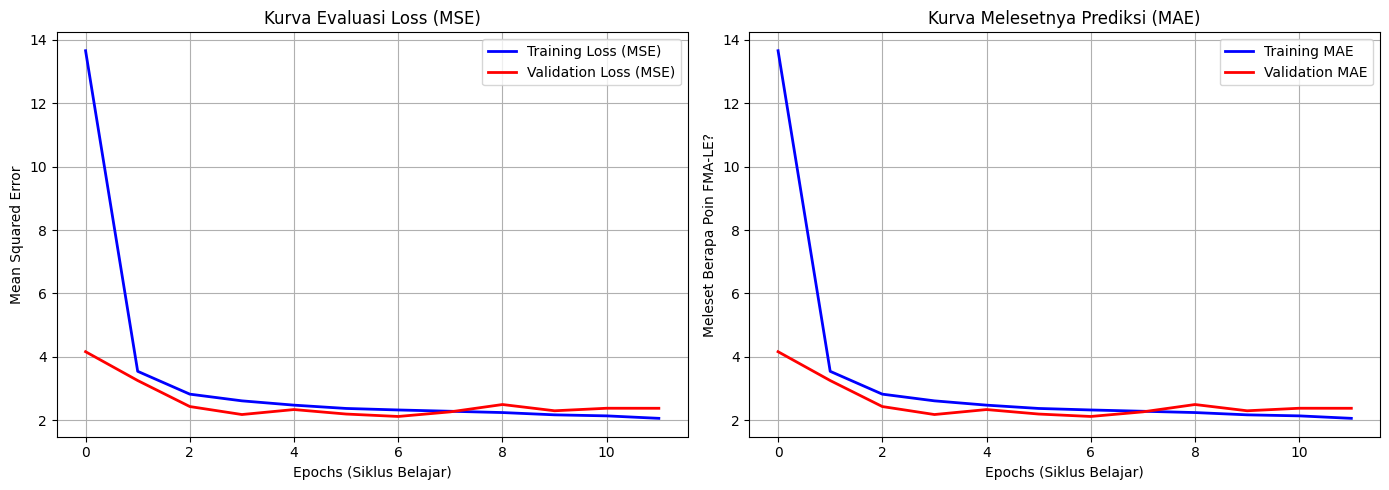


Pelatihan Selesai! Model terbaik telah disimpan sebagai 'model_gait_cva_terbaik.h5'


In [ ]:
# 3. VISUALISASI KURVA PEMBELAJARAN
plt.figure(figsize=(14, 5))

# Plot 1: Mean Squared Error (MSE) - Kurva Loss Utama
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss (MSE)', color='blue', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss (MSE)', color='red', linewidth=2)
plt.title('Kurva Evaluasi Loss (MSE)')
plt.xlabel('Epochs (Siklus Belajar)')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True)

# Plot 2: Mean Absolute Error (MAE) - Selisih Poin Keparahan Aktual
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Training MAE', color='blue', linewidth=2)
plt.plot(history.history['val_mae'], label='Validation MAE', color='red', linewidth=2)
plt.title('Kurva Melesetnya Prediksi (MAE)')
plt.xlabel('Epochs (Siklus Belajar)')
plt.ylabel('Meleset Berapa Poin FMA-LE?')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print("\nPelatihan Selesai! Model terbaik telah disimpan sebagai 'model_gait_cva_terbaik.h5'")

Langkah 6: Memulai Evaluasi Final pada Data Testing (10% Data Tersembunyi)...
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step

[HASIL UJIAN FINAL (TEST SET)]
Mean Squared Error (MSE)       : 8.2778
Root Mean Squared Error (RMSE) : 2.8771 Poin FMA-LE
Mean Absolute Error (MAE)      : 1.3950 Poin FMA-LE
R-Squared (R2)                 : 0.6471

-> Bagus! Terdapat korelasi yang positif dan kuat antara sensor dan tingkat keparahan stroke.


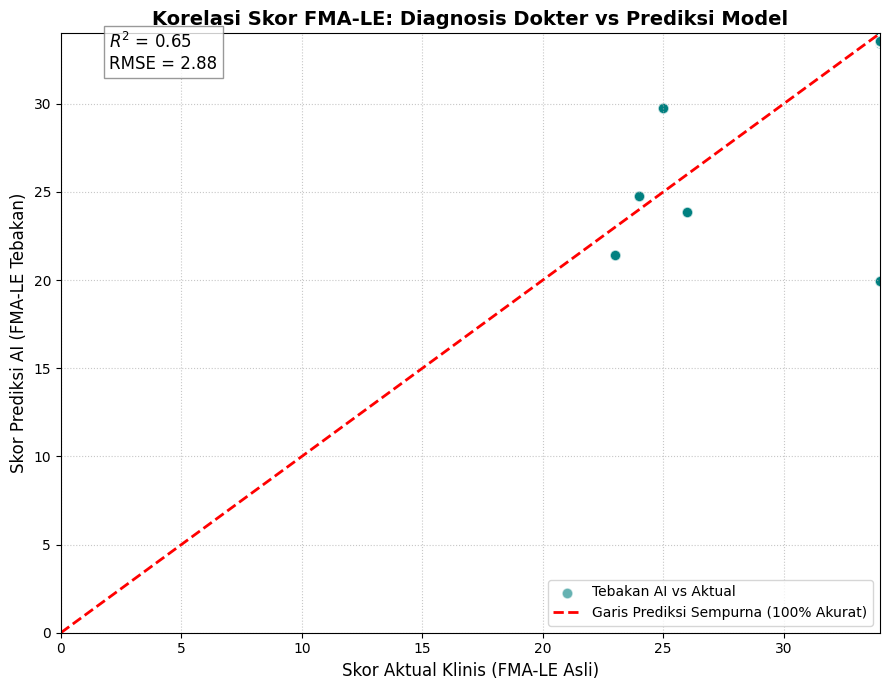


Contoh Komparasi Langsung (10 Jendela Acak Pertama):
Data ke-01 | Aktual: 23.0 | Prediksi AI: 21.4  (Meleset: 1.6 poin)
Data ke-02 | Aktual: 23.0 | Prediksi AI: 21.4  (Meleset: 1.6 poin)
Data ke-03 | Aktual: 23.0 | Prediksi AI: 21.4  (Meleset: 1.6 poin)
Data ke-04 | Aktual: 23.0 | Prediksi AI: 21.4  (Meleset: 1.6 poin)
Data ke-05 | Aktual: 23.0 | Prediksi AI: 21.4  (Meleset: 1.6 poin)
Data ke-06 | Aktual: 23.0 | Prediksi AI: 21.4  (Meleset: 1.6 poin)
Data ke-07 | Aktual: 23.0 | Prediksi AI: 21.4  (Meleset: 1.6 poin)
Data ke-08 | Aktual: 23.0 | Prediksi AI: 21.4  (Meleset: 1.6 poin)
Data ke-09 | Aktual: 23.0 | Prediksi AI: 21.4  (Meleset: 1.6 poin)
Data ke-10 | Aktual: 23.0 | Prediksi AI: 21.4  (Meleset: 1.6 poin)


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

print("Langkah 6: Memulai Evaluasi Final pada Data Testing (10% Data Tersembunyi)...")

# 1. Menyuruh AI menebak skor pasien di data Test
y_pred = model.predict([X_sensor_test, X_meta_test]).flatten()

# 2. Menghitung semua Metrik Evaluasi
test_mse = mean_squared_error(y_test, y_pred)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)

print("\n=========================================")
print(f"[HASIL UJIAN FINAL (TEST SET)]")
print(f"Mean Squared Error (MSE)       : {test_mse:.4f}")
print(f"Root Mean Squared Error (RMSE) : {test_rmse:.4f} Poin FMA-LE")
print(f"Mean Absolute Error (MAE)      : {test_mae:.4f} Poin FMA-LE")
print(f"R-Squared (R2)                 : {test_r2:.4f}")
print("=========================================\n")

if test_r2 > 0.7:
    print("-> Sangat Hebat! Model memiliki korelasi prediktif yang sangat kuat.")
elif test_r2 > 0.5:
    print("-> Bagus! Terdapat korelasi yang positif dan kuat antara sensor dan tingkat keparahan stroke.")
else:
    print("-> Kinerja cukup, namun model mungkin kesulitan memprediksi beberapa variasi data yang ekstrem.")

# 3. Visualisasi Scatter Plot (Tebakan AI vs Diagnosis Asli)
plt.figure(figsize=(9, 7))
# Plot titik-titik tebakan AI
plt.scatter(y_test, y_pred, alpha=0.6, color='teal', edgecolor='white', s=60, label='Tebakan AI vs Aktual')

# Buat garis referensi diagonal (Jika tebakan 100% akurat, titik-titik akan berada di garis ini)
plt.plot([0, 34], [0, 34], 'r--', linewidth=2, label='Garis Prediksi Sempurna (100% Akurat)')

# Menambahkan anotasi metrik ke dalam grafik
plt.text(2, 32, f'$R^2$ = {test_r2:.2f}\nRMSE = {test_rmse:.2f}',
         fontsize=12, bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

plt.title('Korelasi Skor FMA-LE: Diagnosis Dokter vs Prediksi Model', fontsize=14, fontweight='bold')
plt.xlabel('Skor Aktual Klinis (FMA-LE Asli)', fontsize=12)
plt.ylabel('Skor Prediksi AI (FMA-LE Tebakan)', fontsize=12)
plt.xlim(0, 34)
plt.ylim(0, 34)
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

# 4. Tampilkan perbandingan langsung untuk 10 sampel acak
print("\nContoh Komparasi Langsung (10 Jendela Acak Pertama):")
for i in range(10):
    selisih = abs(y_test[i] - y_pred[i])
    print(f"Data ke-{i+1:02d} | Aktual: {y_test[i]:.1f} | Prediksi AI: {y_pred[i]:.1f}  (Meleset: {selisih:.1f} poin)")

In [ ]:
errors = np.abs(y_test - y_pred)

for t in [1,2,3,5]:
    acc = np.mean(errors <= t) * 100
    print(f"Error ≤ {t} poin: {acc:.2f}%")

Error ≤ 1 poin: 69.06%
Error ≤ 2 poin: 81.52%
Error ≤ 3 poin: 92.38%
Error ≤ 5 poin: 96.77%
